In [4]:
import os 
import cv2
import glob
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import scipy.stats as stats
import seaborn as sns
import pandas as pd
from sklearn.metrics import roc_curve
import re
import math
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,precision_score, recall_score, f1_score
import joblib
import time
from ultralytics import YOLO
import maesyori

In [ ]:
import os
import cv2
import maesyori

# 入力元と出力先のベースパス
input_base = "/home/data/test_SVM/org"
output_base = "/home/data/test_SVM/crop"

# クラスインスタンス（パディングと保存先は後で変更）
padding = 30

for category in ['A', 'B', 'C']:
    input_dir = os.path.join(input_base, category)
    output_dir = os.path.join(output_base, category)

    os.makedirs(output_dir, exist_ok=True)

    cropper = maesyori.BB_crop(padding=padding, save_dir=output_dir)
    masker = maesyori.MaskCreator()

    for filename in os.listdir(input_dir):
        if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
            image_path = os.path.join(input_dir, filename)
            image = cv2.imread(image_path)

            if image is None:
                print(f"⚠ 読み込み失敗: {image_path}")
                continue

            mask = masker.create_mask(image)
            cropper.save(image, mask, filename="cropped_" + filename)


In [ ]:
import os
import glob
import cv2
import numpy as np
from maesyori import BB_mask, Yolo_mask  # 自作モジュール
from ultralytics import YOLO

# === YOLOモデルパス ===
yolo_seg_model_path = "/home/YOLO/-327_seg/datasets/train2/weights/best.pt"

# === 入力と出力のパス ===
input_base = "/home/data/test_SVM/crop"
output_bb_base = "/home/data/test_SVM/BB2mask_BB"
output_yolo_base = "/home/data/test_SVM/BB2mask_YOLO"

# === MaskCreatorクラス ===
class MaskCreator:
    def __init__(self, lower_hsv=None, upper_hsv=None):
        self.lower_hsv = lower_hsv if lower_hsv is not None else np.array([20, 100, 100])
        self.upper_hsv = upper_hsv if upper_hsv is not None else np.array([255, 255, 255])

    def create_mask(self, image_bgr):
        hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
        mask = cv2.inRange(hsv, self.lower_hsv, self.upper_hsv)
        return cv2.bitwise_not(mask)


# === YOLOマスク生成器インスタンス作成 ===
yolo_mask_creator = Yolo_mask(model_path=yolo_seg_model_path)

for grade in ["A", "B", "C"]:
    crop_dir = os.path.join(input_base, grade)
    bb_output_dir = os.path.join(output_bb_base, grade)
    yolo_output_dir = os.path.join(output_yolo_base, grade)

    os.makedirs(bb_output_dir, exist_ok=True)
    os.makedirs(yolo_output_dir, exist_ok=True)

    # === BB方式マスク保存 ===
    bb_mask_creator = BB_mask(padding=30, save_dir=bb_output_dir)

    for img_path in glob.glob(os.path.join(crop_dir, "*.JPEG")):
        filename = os.path.basename(img_path)
        img = cv2.imread(img_path)

        # MaskCreatorインスタンス作成
        # mask_creator = MaskCreator()

        # # BB方式でマスクを作成し、保存
        # mask = mask_creator.create_mask(img)
        # bb_mask_creator.save(img, filename="mask_" + filename)

        # === YOLO方式マスク保存 ===
        # フォルダごとに動的に保存先を切り替える
        yolo_mask_creator.generate_mask(img_path, save_dir=yolo_output_dir)


In [1]:
import os
import cv2
import numpy as np
# from maesyori import BB2BBmask
import maesyori

# 入出力のベースパス
input_base = "/home/data/test_SVM/org"
output_bb_base = "/home/data/test_SVM/BB2mask_BB"

# HSVの範囲は必要に応じて調整可能
lower_hsv = np.array([20, 100, 100])
upper_hsv = np.array([255, 255, 255])

# クラスのインスタンス作成
mask_creator = maesyori.BB2BBmask(lower_hsv=lower_hsv, upper_hsv=upper_hsv)

# A, B, C フォルダを処理
for grade in ["A", "B", "C"]:
    input_dir = os.path.join(input_base, grade)
    output_dir = os.path.join(output_bb_base, grade)
    os.makedirs(output_dir, exist_ok=True)

    # フォルダ内の画像ファイルを処理
    for filename in os.listdir(input_dir):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.jpeg')):
            input_path = os.path.join(input_dir, filename)
            output_path = os.path.join(output_dir, "mask_" + filename)

            image = cv2.imread(input_path)
            if image is None:
                print(f"読み込み失敗: {input_path}")
                continue

            try:
                # マスク作成と切り取り
                mask_inv = mask_creator.create_mask(image)
                _, cropped_mask = mask_creator.crop_image(image, mask_inv)

                # マスク画像を保存
                mask_creator.save_mask(cropped_mask, output_path)
                print(f"保存成功: {output_path}")

            except Exception as e:
                print(f"エラー: {filename} - {e}")


/usr/local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


FlashAttention is not available on this device. Using scaled_dot_product_attention instead.

image 1/1 /home/data/maesyori_img/collage_1.jpg: 320x640 24 shiitake_bboxs, 25.9ms
Speed: 1.7ms preprocess, 25.9ms inference, 0.4ms postprocess per image at shape (1, 3, 320, 640)
✔ Cropped image saved to: /home/test_hozon/crop_0.jpg

0: 640x544 1 shiitake, 28.9ms
Speed: 1.0ms preprocess, 28.9ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 544)
✔ Mask image saved to: /home/test_hozon/mask_crop_0.jpg
✔ Cropped image saved to: /home/test_hozon/crop_1.jpg

0: 640x640 1 shiitake, 43.1ms
Speed: 1.8ms preprocess, 43.1ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)
✔ Mask image saved to: /home/test_hozon/mask_crop_1.jpg
✔ Cropped image saved to: /home/test_hozon/crop_2.jpg

0: 608x640 1 shiitake, 27.1ms
Speed: 0.9ms preprocess, 27.1ms inference, 0.6ms postprocess per image at shape (1, 3, 608, 640)
✔ Mask image saved to: /home/test_hozon/mask_crop_2.jpg
✔ Cropped ima

In [ ]:
#前処理フェーズ
#yoloでやるときにちゃんと修正
data_int = "0327_jikuari"
data_out = "jikuari_maesyori"
input_folders = [
    f"/home/data/{data_int}/org/A",
    f"/home/data/{data_int}/org/B",
    f"/home/data/{data_int}/org/C",
]

mask_output_folders = [
    f"/home/data/{data_out}/maskBB/A",
    f"/home/data/{data_out}/maskBB/B",
    f"/home/data/{data_out}/maskBB/C",
]
    
crop_output_folders = [
    f"/home/data/{data_out}/cropBB/A",
    f"/home/data/{data_out}/cropBB/B",
    f"/home/data/{data_out}/cropBB/C",
]

maskedimg_output_folders = [
    f"/home/data/{data_out}/maskedBB/A",
    f"/home/data/{data_out}/maskedBB/B",
    f"/home/data/{data_out}/maskedBB/C",
]

# 出力フォルダを作成
for folder in mask_output_folders:
    os.makedirs(folder, exist_ok=True)
for folder in crop_output_folders:
    os.makedirs(folder, exist_ok=True)
for folder in maskedimg_output_folders:
    os.makedirs(folder, exist_ok=True)

for input_folder, mask_output_folder,crop_output_folder,maskedimg_output_folder in zip(input_folders, mask_output_folders,crop_output_folders,maskedimg_output_folders):
    for file in os.listdir(input_folder):
        # 画像ファイルのみを処理
        if file.endswith(('.png', '.jpg', '.jpeg', '.bmp', '.JPEG')):
            name = os.path.basename(file).replace(".JPEG", "")
            file_path = os.path.join(input_folder, file)

            # 画像を読み込む
            image = cv2.imread(file_path)

            # BGRからHSVに変換
            hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

            # 青色の範囲を定義
            lower_blue = np.array([20, 100, 100])
            upper_blue = np.array([255, 255, 255])

            # ブルーバックのマスクを作成
            mask = cv2.inRange(hsv, lower_blue, upper_blue)

            # マスクの反転（対象物を白、背景を黒にする）
            mask_inv = cv2.bitwise_not(mask)

            # 境界を検出
            contours, _ = cv2.findContours(mask_inv, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

            # 最大の輪郭を取得
            largest_contour = max(contours, key=cv2.contourArea)

            # 対象物を切り取るための境界ボックスを取得
            x, y, w, h = cv2.boundingRect(largest_contour)
            cropped_image = image[y:y+h, x:x+w]
            cropped_mask = mask_inv[y:y+h, x:x+w]
            masked_cropped_image = cv2.bitwise_and(cropped_image, cropped_image, mask=cropped_mask)
            
            mask_output_file_path = os.path.join(mask_output_folder, file)
            crop_output_file_path = os.path.join(crop_output_folder, file)
            maskedimg_output_file_path = os.path.join(maskedimg_output_folder, file)
        
            # 切り取った画像を保存
            cv2.imwrite(mask_output_file_path, cropped_mask)
            cv2.imwrite(crop_output_file_path, cropped_image)
            cv2.imwrite(maskedimg_output_file_path, masked_cropped_image)

In [5]:
#閾値の学習フェーズ
outputfile = f"/home/data/{data}/keijo_mse.csv"
inputfolder_lists = [
    f"/home/data/{data}/maskBB/A",
    f"/home/data/{data}/maskBB/B",
    f"/home/data/{data}/maskBB/C",
]

#形状
outputfile = f"/home/data/{data}/keijo_mse.csv"
one_dimensional_data_dict = {}
evaluation_results = {}

for folder in inputfolder_lists:
    folder_name = os.path.basename(folder)
    image_paths = glob.glob(os.path.join(folder, '*.JPEG'))
    
    # 画像ファイル数をカウント
    num_images = len(image_paths)
    print(f"Folder {folder_name} contains {num_images} images.")

    for img_path in image_paths:
        # 画像の読み込み
        mask = cv2.imread(img_path)

        # グレースケール画像に変換
        gray = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)

        # 二値化
        _, th = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        # 輪郭を検出し、最大の輪郭を取得
        contours, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            continue
        max_contour = max(contours, key=cv2.contourArea)

        # 最小外接円を取得
        (x, y), radius = cv2.minEnclosingCircle(max_contour)
        radius = int(radius)

        # 重心を計算
        M = cv2.moments(max_contour)
        if M["m00"] != 0:
            cX = int(M["m10"] / M["m00"])
            cY = int(M["m01"] / M["m00"])
        else:
            cX, cY = 0, 0
        center = (cX, cY)

        # 極座標変換
        h, w = gray.shape
        flags = cv2.INTER_CUBIC + cv2.WARP_FILL_OUTLIERS + cv2.WARP_POLAR_LINEAR
        linear_polar = cv2.warpPolar(gray, (w, h), center, radius, flags)

        # 行ごとの黒ピクセル数をカウント
        black_pixel_count = np.sum(linear_polar == 0, axis=1)
        file_name = os.path.basename(img_path)
        one_dimensional_data_dict[file_name] = black_pixel_count

        # 真円の場合の理想データ（黒ピクセル数が0）
        y_pseudo = np.zeros_like(black_pixel_count)

        # 評価指標の計算
        mae = mean_absolute_error(y_pseudo, black_pixel_count)
        mse = mean_squared_error(y_pseudo, black_pixel_count)
        rmse = np.sqrt(mse)  # RMSEを計算

        evaluation_results[file_name] = {
            'MSE': mse, 
            'folder': folder_name
        }

# MAE、MSE、RMSEの抽出
file_names = list(evaluation_results.keys())
mse_values = [metrics['MSE'] for metrics in evaluation_results.values()]
folders = [metrics['folder'] for metrics in evaluation_results.values()]
# DataFrame に変換
df_mse = pd.DataFrame(evaluation_results).T  # .T で転置して見やすくする
df_mse.reset_index(inplace=True)
df_mse.rename(columns={'index': 'filename'}, inplace=True)
# df_mse.rename(columns={'Folder': 'folder'}, inplace=True)
df_mse['filename'] = df_mse['filename'].astype(str)  # filenameを文字列型に
df_mse['MSE'] = df_mse['MSE'].astype(float)  # MSEを浮動小数型に
df_mse['folder'] = df_mse['folder'].astype(str)  # folderを文字列型に

output_file = f"/home/data/{data}/size_pixelcounts.csv"
input_folders = [
    f"/home/data/{data}/maskBB/A",
    f"/home/data/{data}/maskBB/B",
    f"/home/data/{data}/maskBB/C",
]
# フォルダごとのラベル設定
labels = ['Folder A', 'Folder B', 'Folder C']

# 結果を保存するリスト
data_list = []

# データの収集
for input_folder, label in zip(input_folders, labels):
    for file in os.listdir(input_folder):
        if file.endswith(('.png', '.jpg', '.jpeg', '.bmp', '.JPEG')):
            file_path = os.path.join(input_folder, file)
            image = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)

            # 二値化
            _, image = cv2.threshold(image, 128, 255, cv2.THRESH_BINARY)

            # 白ピクセルのカウント
            white_pixel_count = np.sum(image == 255)

            # ファイル名（拡張子を除去）
            # filename = os.path.splitext(file)[0]
            filename = file

            # データをリストに追加
            data_list.append([filename, white_pixel_count, label])

# データフレームを作成
df_size = pd.DataFrame(data_list, columns=["filename", "size_count", "folder"])
df_size['folder'] = df_size['folder'].str.replace('Folder ', '')
df_size['filename'] = df_size['filename'].astype(str)  # filenameを文字列型に
df_size['size_count'] = df_size['size_count'].astype(float)  # size_countを浮動小数型に
df_size['folder'] = df_size['folder'].astype(str)  # folderを文字列型に

#襞領域
def fmxy(absfxy, mxy):
    return np.where(absfxy > mxy, 1, 0)

def Min(a, b):
    return np.minimum(a, b)

def G12(theta1, theta2):
    condition1 = (theta2 - np.pi < theta1) & (theta1 < theta2) & (theta2 >= 0)
    result1 = np.abs(theta1 - theta2)
    condition2 = (-np.pi < theta1) & (theta1 < (theta2 - np.pi)) & (theta2 >= 0)
    result2 = theta2 - 2 * np.pi - theta1
    condition3 = (-np.pi < theta1) & (theta1 < (theta2 + np.pi)) & (theta2 < 0)
    result3 = np.abs(theta1 - theta2)
    condition4 = (theta2 + np.pi < theta1) & (theta1 < np.pi) & (theta2 < 0)
    result4 = theta1 - theta2 - 2 * np.pi
    result = np.where(condition1, result1, 
             np.where(condition2, result2, 
             np.where(condition3, result3, 
             np.where(condition4, result4, 0))))
    return result

def SquareSum(I, x, y, h, w, n):
    x1, y1 = x - n, y - n
    x2, y2 = x + n, y + n
    x1, x2 = max(x1, 0), min(x2, w - 2)
    y1, y2 = max(y1, 0), min(y2, h - 2)
    total = I[y2, x2] - I[y1, x2] - I[y2, x1] + I[y1, x1]
    return total

def sdis(Iruv, Imyv, x, y, h, w, n):
    Tr = SquareSum(Iruv, x, y, h, w, n)
    Tm = SquareSum(Imyv, x, y, h, w, n)
    return Tr / Tm

# パラメータ
n = 15
data_list = []

img_folders = [
    f"/home/data/{data}/maskedBB/A",
    f"/home/data/{data}/maskedBB/B",
    f"/home/data/{data}/maskedBB/C",
]
mask_folders = [
    f"/home/data/{data}/maskBB/A",
    f"/home/data/{data}/maskBB/B",
    f"/home/data/{data}/maskBB/C",
]

for img_folder, mask_folder in zip(img_folders, mask_folders):
    folder_name = os.path.basename(img_folder)
    img_files = os.listdir(img_folder)
    mask_files = os.listdir(mask_folder)
    
    for img_file, mask_file in zip(img_files, mask_files):
        img_path = os.path.join(img_folder, img_file)
        mask_path = os.path.join(mask_folder, mask_file)
        
        # 重心 (1)
        img = cv2.imread(img_path)
        mask_img = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        masked_img = cv2.imread(img_path)
        h, w = img.shape[:2]
        
        # 重心を計算
        x_sum, y_sum, count = 0, 0, 0
        for i in range(h):
            for j in range(w):
                if mask_img[i][j] == 255:
                    x_sum += j
                    y_sum += i
                    count += 1
        xc, yc = (x_sum / count, y_sum / count) if count > 0 else (0, 0)
        
        # fθ(x,y)(勾配の方向), |f(x,y)| (2)(3)
        image = cv2.cvtColor(masked_img, cv2.COLOR_BGR2GRAY)
        fdy, fdx = np.gradient(image)
        f0xy = np.arctan2(fdy, fdx)
        absfxy = np.uint8(np.sqrt(fdx**2 + fdy**2))
        
        # C0(x,y)：中心からのベクトルの角度
        height, width = image.shape
        C0xy = np.zeros((height, width))
        for y in range(height):
            for x in range(width):
                dx, dy = x - xc, y - yc
                C0xy[y, x] = np.arctan(dy / dx) if dx != 0 else 0
        
        # f(xy)の勾配ベクトルが中心から(x,y)へのベクトルへ垂直か評価する関数fdisxy(4)(5)
        fdisxy = Min(G12(C0xy + np.pi/2, f0xy)**2, G12(C0xy - np.pi/2, f0xy)**2)
        
        # mxy = |fxy|に対する2n+1×2n+1のメディアンフィルタリングの結果
        kernel_size = 2 * n + 1
        mxy = np.uint8(cv2.medianBlur(absfxy, kernel_size))
        
        # rdis (8)
        rdisxy = fmxy(absfxy, mxy) * fdisxy
        
        # Iruv, Imyv (9)(10)
        Iruv = cv2.integral(rdisxy)
        Imyv = cv2.integral(fmxy(absfxy, mxy).astype(np.uint8))
        
        # sdis計算
        sdisval = np.zeros((image.shape[0], image.shape[1]))
        for y in range(0, image.shape[0], 1):
            for x in range(0, image.shape[1], 1):
                sdisval[y, x] = sdis(Iruv, Imyv, x, y, h, w, n)
        sdisval = np.nan_to_num(sdisval, nan=0.0, posinf=0.0, neginf=0.0)
        
        # 閾値処理
        T = 0.2
        hxy = np.where(sdisval < T, 1, 0)
        hxy2 = cv2.bitwise_and(hxy, hxy, mask=mask_img)
        
        # シイタケ領域のPixel数を計算
        count_mask = np.sum(mask_img == 255)
        count_hida = np.sum(hxy2 == 1)
        R = count_hida / count_mask if count_mask > 0 else 0
        data_list.append((img_file, R,folder_name))
        
output_csv = f"/home/data/{data}/R_values.csv"
df_r = pd.DataFrame(data_list, columns=["filename", "R","folder"])
df_r['filename'] = df_r['filename'].astype(str)  # filenameを文字列型に
df_r['R'] = df_r['R'].astype(float)  # Rを浮動小数型に
df_r['folder'] = df_r['folder'].astype(str)  # folderを文字列型に

# `folder` カラムを削除
df_mse = df_mse.drop(columns=['folder'])
df_size = df_size.drop(columns=['folder'])

# `filename` をキーとして結合
df_merge = df_mse.merge(df_size, on="filename", how="inner").merge(df_r, on="filename", how="inner")

# 'folder' を 'Label' に変更
df_merge['Label'] = df_merge['folder'].apply(lambda x: 0 if x == 'A' else (1 if x == 'B' else 2))

# 'folder' カラムを削除
df_merge = df_merge.drop(columns=['folder'])
output_csv = f"/home/data/{data}/merged_data.csv"
df_merge.to_csv(output_csv, index=False)

Folder A contains 48 images.
Folder B contains 30 images.
Folder C contains 38 images.


/tmp/ipykernel_1584000/2595198318.py:159: RuntimeWarning: invalid value encountered in scalar divide
  return Tr / Tm
/tmp/ipykernel_1584000/2595198318.py:159: RuntimeWarning: divide by zero encountered in scalar divide
  return Tr / Tm


In [8]:
csv = "/home/data/test_SVM/merged_data.csv"

# === モデルとスケーラーの読み込み ===
model_path = "svm_model.pkl"
scaler_path = "scaler.pkl"

svm_model = joblib.load(model_path)
scaler = joblib.load(scaler_path)

# === 新しいデータの読み込み ===
new_data_csv = f"{csv}"  # 新しいデータ
df_new = pd.read_csv(new_data_csv)

# === 特徴量の抽出と標準化 ===
X_new = df_new[["MSE", "size_count", "R"]]  # 学習時と同じ特徴量を使用
X_new = scaler.transform(X_new)  # 標準化

# === 予測 ===
y_pred_new = svm_model.predict(X_new)

# 結果をDataFrameに追加
df_new["Predicted_Label"] = y_pred_new

# 予測結果の確認
print(df_new[["MSE", "size_count", "R", "Predicted_Label"]])

# CSVとして保存（オプション）
df_new.to_csv(f"/home/data/test_SVM/seido.csv", index=False)

             MSE  size_count         R  Predicted_Label
0    1620.546875    156181.0  0.029932                0
1     846.630342    165731.0  0.022063                0
2    1826.250000    217898.0  0.033801                0
3    2021.876611    221644.0  0.027558                0
4     760.463415    137450.0  0.017892                0
..           ...         ...       ...              ...
111   934.046624    274552.0  0.465006                2
112  1498.111324    247262.0  0.399253                2
113  1800.068182    243032.0  0.370821                2
114  1307.536062    202447.0  0.566033                2
115  1224.985586    238736.0  0.439945                2

[116 rows x 4 columns]


Accuracy: 0.8621
Precision: 0.8540
Recall: 0.8548
F1: 0.8542


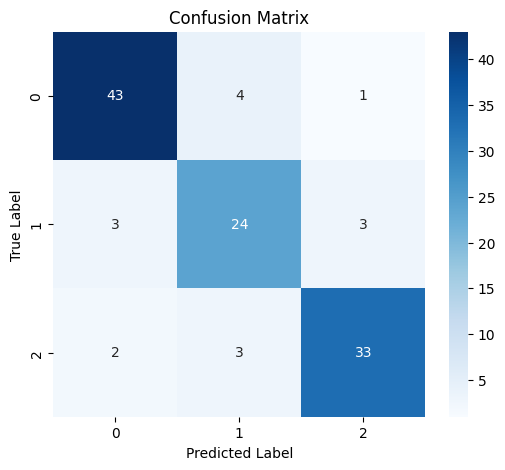

In [9]:
# 精度の表示
accuracy = accuracy_score(df_new["Label"], df_new["Predicted_Label"])
precision = precision_score(df_new["Label"], df_new["Predicted_Label"], average='macro')
recall = recall_score(df_new["Label"], df_new["Predicted_Label"], average='macro')
f1 = f1_score(df_new["Label"], df_new["Predicted_Label"], average='macro')
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1: {f1:.4f}")
# 混同行列の可視化
cm = confusion_matrix(df_new["Label"], df_new["Predicted_Label"])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0, 1, 2], yticklabels=[0, 1, 2])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()